# Analysing scRepresenter embeddings

In this notebook we will look the structure of the embedding object produced by scRepresenter, as well as some potential use cases. If you haven't already, please see the Preprocessing, Training and Classification notebooks.

In [ ]:
#install required plotting packages
%pip install plotly matplotlib seaborn

In [ ]:
#imports
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import gdown
import zipfile
if os.path.basename(os.getcwd()) == 'scripts':
    os.chdir('..')


First, download and unzip the dataset and corresponding predicitons that we will use for analysis

In [4]:
url = f"https://drive.google.com/uc?id=19NVlnrTCTDOW9tHsVgjekZEyGVTTS1wJ"
file = "./output/final_objects.zip"
gdown.download(url, file, quiet=False, fuzzy=True)

with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall("./output")

Downloading...
From (original): https://drive.google.com/uc?id=19NVlnrTCTDOW9tHsVgjekZEyGVTTS1wJ
From (redirected): https://drive.google.com/uc?id=19NVlnrTCTDOW9tHsVgjekZEyGVTTS1wJ&confirm=t&uuid=822f02db-a5ff-4d69-b6f7-0f943382113d
To: /home/guilherme/scRepresenter/output/final_objects.zip
100%|██████████| 848M/848M [00:36<00:00, 23.3MB/s] 


Read the .h5 dataset into memory and calculate the highest variable genes, which will be usefull for the following analysis

In [5]:
adata = sc.read_h5ad("output/final_objects/All_Predictions.h5ad")
print(adata)

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=True,          # keep only HVGs in adata.var / adata.X
    flavor="seurat_v3"    # good default
)
print("Number of HVGs used:", adata.n_vars)

AnnData object with n_obs × n_vars = 14511 × 3000
    obs: 'celltype', 'PPI prediction', 'FM prediction', 'Avg. FM and PPI prediction', 'Con. FM and PPI prediction', 'PCA prediction', 'GO common-terms prediction', 'Avg. FM and GO common-terms prediction', 'Con. FM and GO common-terms prediction', 'GO word2vec prediction', 'Avg. FM and GO word2vec prediction', 'Con. FM and GO word2vec prediction'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'Avg. FM and GO common-terms embeddings', 'Avg. FM and GO word2vec embeddings', 'Avg. FM and PPI embeddings', 'Con. FM and GO common-terms embeddings', 'Con. FM and GO word2vec embeddings', 'Con. FM and PPI embeddings', 'FM embeddings', 'GO common-terms embeddings', 'GO word2vec embeddings', 'PPI embeddings'


/home/guilherme/scRepresenter/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Number of HVGs used: 2000


## Elbow Plot

This simple plot allows us to decide how many principal components from the embeddings we should keep, by seeing where additional components stop adding meaningful varience to the result.

PCA shape: (14511, 50)


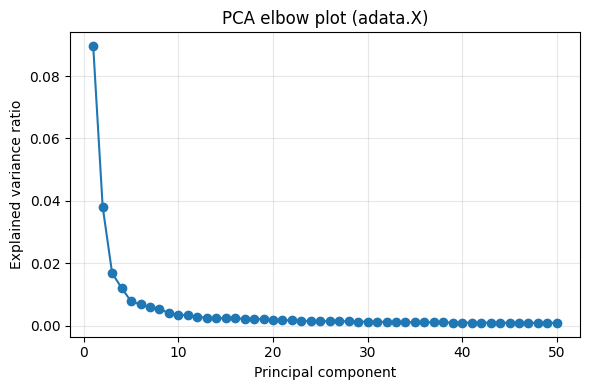

In [6]:

sc.pp.scale(adata, max_value=10)   # clip extreme values
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")
print("PCA shape:", adata.obsm["X_pca"].shape)

# Elbow plot
var_ratio = adata.uns["pca"]["variance_ratio"]
pcs = np.arange(1, len(var_ratio) + 1)

plt.figure(figsize=(6, 4))
plt.plot(pcs, var_ratio, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA elbow plot (adata.X)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## UMAP plots

From the elbow plot we can see how no meaningful variance is gained after 10 dimensions, so that's the number of components we'll use in the following analysis.

Up next we will plot the UMAP of the expression values, to get a notion of the different cell populations in the data.

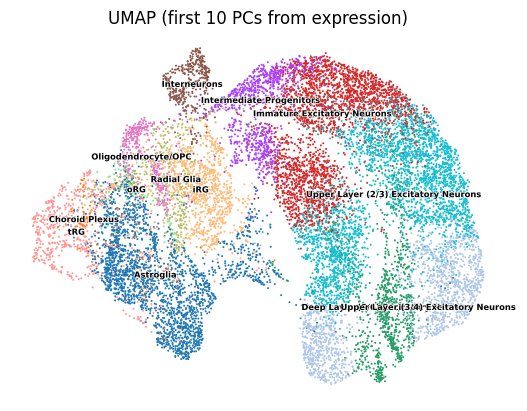

In [7]:

sc.pp.neighbors(
    adata,
    n_pcs=10,        
    use_rep="X_pca" 
)

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="celltype",
    frameon=False,
    title="UMAP (first 10 PCs from expression)",
    legend_loc="on data",  
    legend_fontsize=6,
    legend_fontoutline=1,
)


Now let's see how well each embedding captures the established cell populations, by calculating UMAP for each of the embeddings in the .h5 object

In [8]:
embeddings = [
    "PPI embeddings",
    "GO common-terms embeddings",
    "GO word2vec embeddings",
    "FM embeddings",
    "Avg. FM and PPI embeddings",
    "Con. FM and PPI embeddings",
    "Avg. FM and GO common-terms embeddings",
    "Con. FM and GO common-terms embeddings",
    "Avg. FM and GO word2vec embeddings",
    "Con. FM and GO word2vec embeddings", 
]

for obsm_key in embeddings:
    print(f"Running neighbors + UMAP for: {obsm_key}")
    sc.pp.neighbors(
        adata,
        use_rep=obsm_key,
        n_neighbors=15,
        metric="cosine",
        key_added=obsm_key,     
    )
    sc.tl.umap(
        adata,
        neighbors_key=obsm_key,  
    )
    adata.obsm[f"X_umap_{obsm_key}"] = adata.obsm["X_umap"].copy()



Running neighbors + UMAP for: PPI embeddings
Running neighbors + UMAP for: GO common-terms embeddings
Running neighbors + UMAP for: GO word2vec embeddings
Running neighbors + UMAP for: FM embeddings
Running neighbors + UMAP for: Avg. FM and PPI embeddings
Running neighbors + UMAP for: Con. FM and PPI embeddings
Running neighbors + UMAP for: Avg. FM and GO common-terms embeddings
Running neighbors + UMAP for: Con. FM and GO common-terms embeddings
Running neighbors + UMAP for: Avg. FM and GO word2vec embeddings
Running neighbors + UMAP for: Con. FM and GO word2vec embeddings


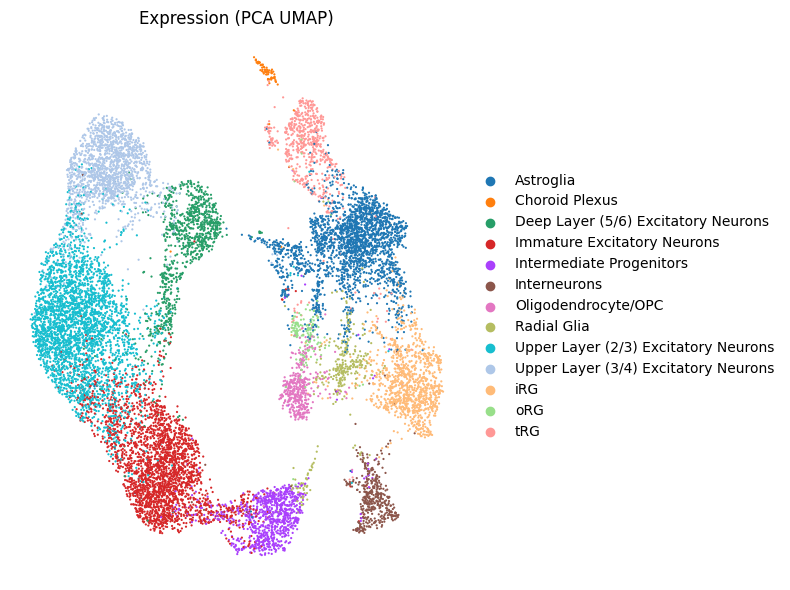

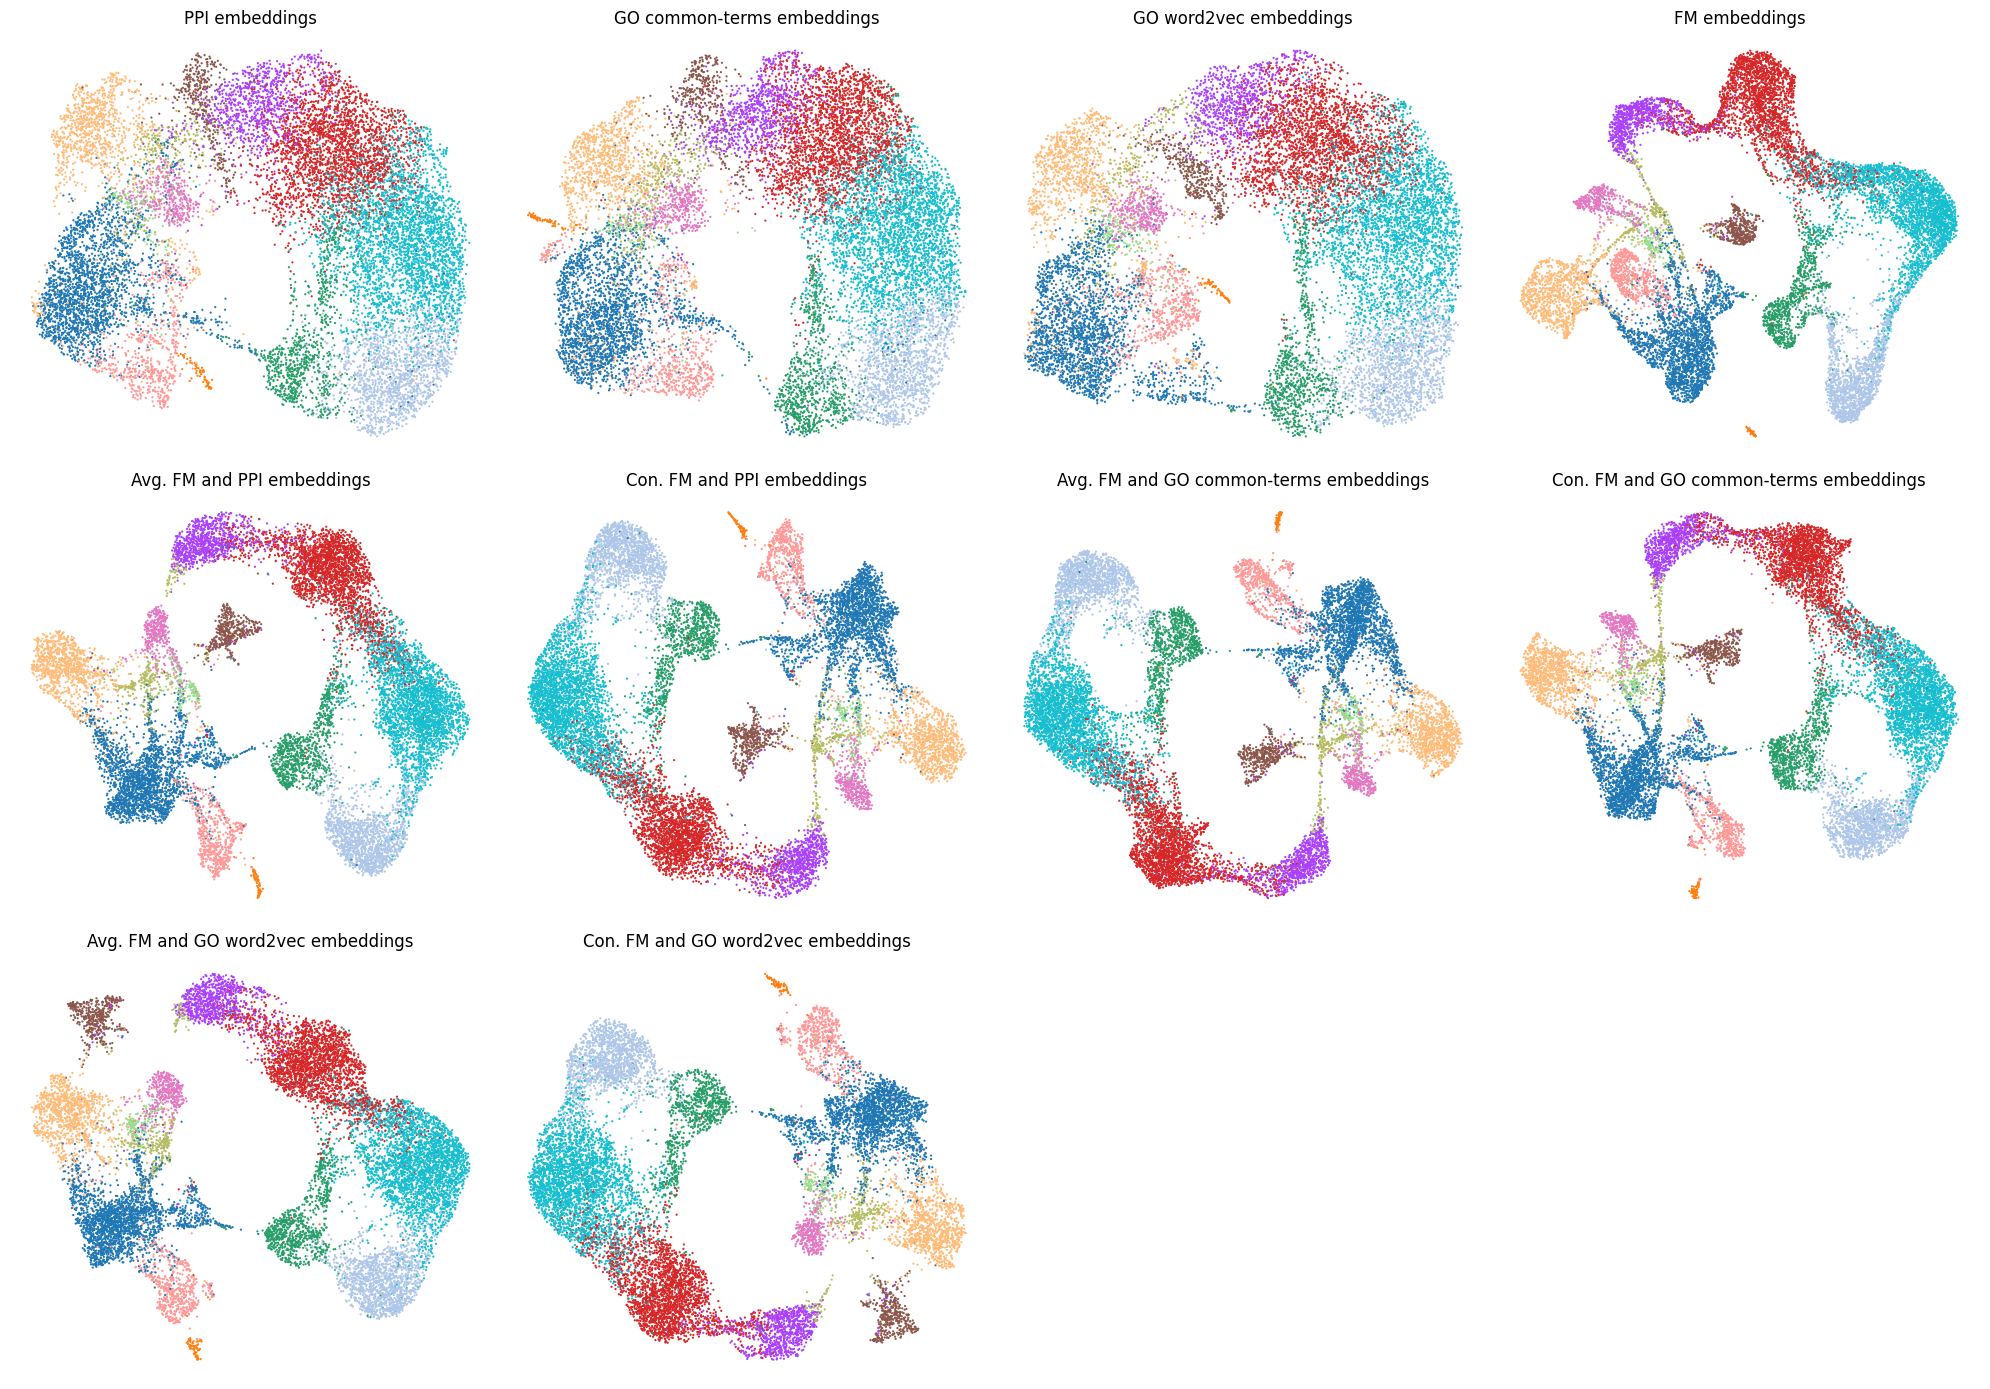

In [ ]:
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig_pca, ax_pca = plt.subplots(figsize=(8, 6))
sc.pl.embedding(
    adata,
    basis="X_umap",
    color="celltype",
    frameon=False,
    ax=ax_pca,
    show=False,
    title="Expression (PCA UMAP)",
    legend_loc="right margin",
    size=10,
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for ax, obsm_key in zip(axes.ravel(), embeddings):
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{obsm_key}",     
        color="celltype",
        frameon=False,
        ax=ax,
        show=False,
        title=obsm_key,
        legend_loc=None,    
        size=10,
    )

axes.ravel()[-1].set_visible(False)
axes.ravel()[-2].set_visible(False)

plt.tight_layout()
plt.show()

## Clustering quality metrics

We can see the quality of our cell embeddings by how well each known cell type cluster is defined. With this goal, we can calculate a variety of cluster quality metrics, mainly the average silhouette width (ASW), the Davies-Bouldin index (DBI) and the Calinski-Harabasz index (CHI).

In [10]:

labels = adata.obs["celltype"].values.to_numpy()

results = []

for obsm_key in embeddings:
    X = adata.obsm[obsm_key]
    print(f"Computing metrics for: {obsm_key} ({obsm_key}, shape {X.shape})")

    asw_euc = silhouette_score(X, labels, metric="euclidean")
    asw_cos = silhouette_score(X, labels, metric="cosine")
    dbi = davies_bouldin_score(X, labels)
    chi = calinski_harabasz_score(X, labels)

    results.append({
        "embedding": obsm_key,
        "ASW_euclidean": asw_euc,
        "ASW_cosine": asw_cos,
        "DBI": dbi,
        "CHI": chi,
    })

metrics_df = pd.DataFrame(results)
metrics_df


Computing metrics for: PPI embeddings (PPI embeddings, shape (14511, 512))
Computing metrics for: GO common-terms embeddings (GO common-terms embeddings, shape (14511, 512))
Computing metrics for: GO word2vec embeddings (GO word2vec embeddings, shape (14511, 512))
Computing metrics for: FM embeddings (FM embeddings, shape (14511, 512))
Computing metrics for: Avg. FM and PPI embeddings (Avg. FM and PPI embeddings, shape (14511, 512))
Computing metrics for: Con. FM and PPI embeddings (Con. FM and PPI embeddings, shape (14511, 1024))
Computing metrics for: Avg. FM and GO common-terms embeddings (Avg. FM and GO common-terms embeddings, shape (14511, 512))
Computing metrics for: Con. FM and GO common-terms embeddings (Con. FM and GO common-terms embeddings, shape (14511, 1024))
Computing metrics for: Avg. FM and GO word2vec embeddings (Avg. FM and GO word2vec embeddings, shape (14511, 512))
Computing metrics for: Con. FM and GO word2vec embeddings (Con. FM and GO word2vec embeddings, shape 

,embedding,ASW_euclidean,ASW_cosine,DBI,CHI
0,PPI embeddings,0.056316,0.217775,1.930575,1040.596876
1,GO common-terms embeddings,0.053906,0.176593,1.978666,1083.036136
2,GO word2vec embeddings,0.060158,0.203368,2.079708,958.141580
3,FM embeddings,0.431138,0.584967,0.993233,2997.017870
4,Avg. FM and PPI embeddings,0.308823,0.504002,1.207131,1883.202837
5,Con. FM and PPI embeddings,0.310098,0.505764,1.203703,1893.366888
6,Avg. FM and GO common-terms embeddings,0.326963,0.504505,1.206624,1944.280335
7,Con. FM and GO common-terms embeddings,0.331214,0.511019,1.204849,2003.604889
8,Avg. FM and GO word2vec embeddings,0.253011,0.443763,1.392798,1514.398758
9,Con. FM and GO word2vec embeddings,0.250056,0.442475,1.393486,1494.182397


### NN Purity

We can also calculate nearest neighbour (nn) purity to measure how many neighbouring cells have the same cell type of a given target cell, to measure cluster cohesion.

In [11]:

def nn_purity(X, labels, k=15, metric="cosine"):
    nn = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)
    neigh_indices = indices[:, 1:]
    neigh_labels = labels[neigh_indices]
    same = (neigh_labels == labels[:, None]).mean(axis=1)
    return same.mean()

nn_results = []

for obsm_key in embeddings:
    X = adata.obsm[obsm_key]
    print(f"Computing nn purity for: {obsm_key} ({obsm_key}, shape {X.shape})")

    purity = nn_purity(X, labels, k=15, metric="cosine")
    nn_results.append({"embedding": obsm_key, "NN purity k15": purity})

nn_df = pd.DataFrame(nn_results)
nn_df


Computing nn purity for: PPI embeddings (PPI embeddings, shape (14511, 512))
Computing nn purity for: GO common-terms embeddings (GO common-terms embeddings, shape (14511, 512))
Computing nn purity for: GO word2vec embeddings (GO word2vec embeddings, shape (14511, 512))
Computing nn purity for: FM embeddings (FM embeddings, shape (14511, 512))
Computing nn purity for: Avg. FM and PPI embeddings (Avg. FM and PPI embeddings, shape (14511, 512))
Computing nn purity for: Con. FM and PPI embeddings (Con. FM and PPI embeddings, shape (14511, 1024))
Computing nn purity for: Avg. FM and GO common-terms embeddings (Avg. FM and GO common-terms embeddings, shape (14511, 512))
Computing nn purity for: Con. FM and GO common-terms embeddings (Con. FM and GO common-terms embeddings, shape (14511, 1024))
Computing nn purity for: Avg. FM and GO word2vec embeddings (Avg. FM and GO word2vec embeddings, shape (14511, 512))
Computing nn purity for: Con. FM and GO word2vec embeddings (Con. FM and GO word2ve

,embedding,NN purity k15
0,PPI embeddings,0.819571
1,GO common-terms embeddings,0.813103
2,GO word2vec embeddings,0.818349
3,FM embeddings,0.881267
4,Avg. FM and PPI embeddings,0.882746
5,Con. FM and PPI embeddings,0.882953
6,Avg. FM and GO common-terms embeddings,0.883780
7,Con. FM and GO common-terms embeddings,0.884079
8,Avg. FM and GO word2vec embeddings,0.883518
9,Con. FM and GO word2vec embeddings,0.883357


Additionally, for a more in depth view of NN purity, we can measure the value per individual cell type.

In [12]:
def nn_purity_per_cluster(X, labels, clusters, k=15, metric="cosine"):
    """
    Compute NN purity for each cluster separately.
    labels   = true cell types (array of strings)
    clusters = assigned cluster labels (array, strings or ints)
    """
    nn = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)
    neigh_indices = indices[:, 1:]  

    neigh_labels = labels[neigh_indices]  
    same_label = (neigh_labels == labels[:, None]).mean(axis=1)  

    df = pd.DataFrame({
        "cluster": clusters,
        "celltype": labels,
        "purity": same_label,
    })

    purity_df = df.groupby("cluster")["purity"].mean().reset_index()

    dom_ct = (
        df.groupby("cluster")["celltype"]
          .agg(lambda x: x.value_counts().idxmax())
          .reset_index()
          .rename(columns={"celltype": "dominant_celltype"})
    )

    out = purity_df.merge(dom_ct, on="cluster")
    return out


cluster_nn_results = []

for obsm_key in embeddings:
    X = adata.obsm[obsm_key]
    print(f"Computing nn purity for: {obsm_key} ({obsm_key}, shape {X.shape})")
    ct = adata.obs["celltype"].values.to_numpy()
    
    df = nn_purity_per_cluster(
        X=X,
        labels=ct,          
        clusters=ct,        
        k=15,
        metric="cosine"
    )
    df["embedding"] = obsm_key
    cluster_nn_results.append(df)

cluster_nn_df = pd.concat(cluster_nn_results, ignore_index=True)

# mean purity per (celltype, embedding)
ct_emb_purity = (
    cluster_nn_df
    .groupby(["dominant_celltype", "embedding"])["purity"]
    .mean()
    .reset_index()
)

pivot_ct = ct_emb_purity.pivot(
    index="dominant_celltype",
    columns="embedding",
    values="purity"
)

pivot = pivot_ct[embeddings]
pivot

Computing nn purity for: PPI embeddings (PPI embeddings, shape (14511, 512))
Computing nn purity for: GO common-terms embeddings (GO common-terms embeddings, shape (14511, 512))
Computing nn purity for: GO word2vec embeddings (GO word2vec embeddings, shape (14511, 512))
Computing nn purity for: FM embeddings (FM embeddings, shape (14511, 512))
Computing nn purity for: Avg. FM and PPI embeddings (Avg. FM and PPI embeddings, shape (14511, 512))
Computing nn purity for: Con. FM and PPI embeddings (Con. FM and PPI embeddings, shape (14511, 1024))
Computing nn purity for: Avg. FM and GO common-terms embeddings (Avg. FM and GO common-terms embeddings, shape (14511, 512))
Computing nn purity for: Con. FM and GO common-terms embeddings (Con. FM and GO common-terms embeddings, shape (14511, 1024))
Computing nn purity for: Avg. FM and GO word2vec embeddings (Avg. FM and GO word2vec embeddings, shape (14511, 512))
Computing nn purity for: Con. FM and GO word2vec embeddings (Con. FM and GO word2ve

embedding,PPI embeddings,GO common-terms embeddings,GO word2vec embeddings,FM embeddings,Avg. FM and PPI embeddings,Con. FM and PPI embeddings,Avg. FM and GO common-terms embeddings,Con. FM and GO common-terms embeddings,Avg. FM and GO word2vec embeddings,Con. FM and GO word2vec embeddings
dominant_celltype,,,,,,,,,,
Astroglia,0.892589,0.879787,0.894839,0.926615,0.926990,0.927047,0.927595,0.928345,0.927191,0.925288
Choroid Plexus,0.906061,0.898990,0.874747,0.928283,0.912121,0.912121,0.924242,0.924242,0.931313,0.930303
Deep Layer (5/6) Excitatory Neurons,0.818856,0.816243,0.843997,0.890184,0.885169,0.887218,0.889619,0.889266,0.891949,0.893856
Immature Excitatory Neurons,0.796316,0.766148,0.770713,0.857536,0.859559,0.860467,0.859715,0.859533,0.859922,0.860233
Intermediate Progenitors,0.773625,0.750455,0.782587,0.828561,0.838543,0.838980,0.837086,0.836503,0.844590,0.845974
Interneurons,0.823047,0.821655,0.820882,0.931168,0.933488,0.933797,0.931941,0.932869,0.923589,0.925754
Oligodendrocyte/OPC,0.805624,0.804632,0.825476,0.871133,0.883706,0.882713,0.880066,0.882217,0.891977,0.888668
Radial Glia,0.514815,0.471895,0.478214,0.701089,0.687364,0.685839,0.691285,0.692810,0.667974,0.671242
Upper Layer (2/3) Excitatory Neurons,0.823171,0.826334,0.823340,0.879106,0.881067,0.880624,0.883597,0.883618,0.881742,0.881046


Finally, we can organize the values in a heatmap plot, to see how they evolve across the different embeddings.

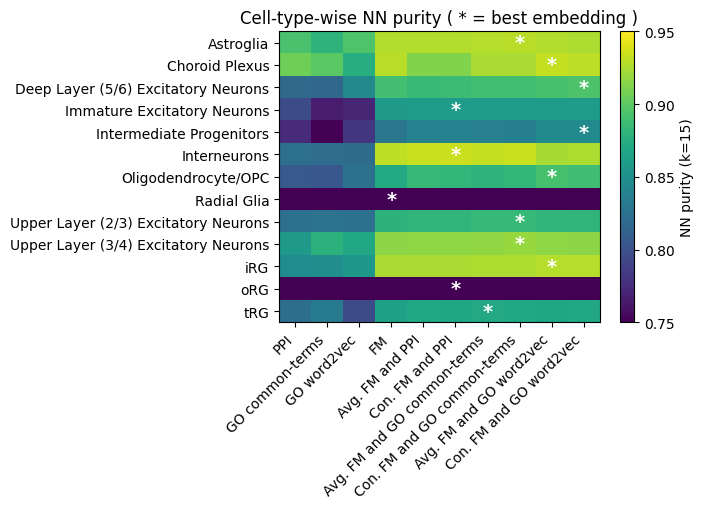

In [13]:

cmap = cm.get_cmap("viridis").copy()
cmap.set_bad(color="lightgray")

vmin = 0.75
vmax = 0.95
norm = colors.Normalize(vmin=vmin, vmax=vmax)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig, ax = plt.subplots(figsize=(7, max(4, 0.4 * len(pivot))))

im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm)

ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_xticklabels(
    [col.replace(" embeddings", "") for col in pivot.columns],
    rotation=45, ha="right"
)
ax.set_yticklabels(pivot.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("NN purity (k=15)")
cbar.set_ticks([0.75, 0.80, 0.85, 0.90, 0.95])   # 👈 custom ticks
cbar.set_ticklabels(["0.75", "0.80", "0.85", "0.90", "0.95"])

data = pivot.values
for i in range(data.shape[0]):
    row = data[i, :]
    if np.all(np.isnan(row)):
        continue
    j = np.nanargmax(row)
    ax.text(
        j, i, "*",
        ha="center", va="center",
        color="white",
        fontsize=14,
        fontweight="bold",
    )

ax.set_title("Cell-type-wise NN purity ( * = best embedding )")
plt.tight_layout()
plt.show()


### Adjusted Rand Index

The adjusted rand index (ARI) is another metric used to measure cluster quality. By comparing the ARI of the established clusters to those produced by leiden clustering, at different resolutions, we can see how the embeddings preserver the underlying biological structure

In [14]:
resolutions = np.linspace(0.3, 1.0, 10)  
ari_records = []

for obsm_key in embeddings:
    print(f"Computing ari for: {obsm_key}")

    nn_key = f"{obsm_key}_nn_ari"
    sc.pp.neighbors(
        adata,
        use_rep=obsm_key,
        n_neighbors=15,
        metric="cosine",
        key_added=nn_key,
    )

    for res in resolutions:
        clust_key = f"{obsm_key}_leiden_res{res:.2f}"
        sc.tl.leiden(
            adata,
            neighbors_key=nn_key,
            key_added=clust_key,
            resolution=float(res),
            random_state=0,
        )
        pred = adata.obs[clust_key].astype("category").values
        ari = adjusted_rand_score(labels, pred)
        del adata.obs[clust_key]

        ari_records.append({"embedding": obsm_key, "resolution": float(res), "ARI": float(ari)})

ari_df = pd.DataFrame(ari_records)
max_ari_df = ari_df.groupby("embedding", as_index=False)["ARI"].max().sort_values("ARI", ascending=False)
print(max_ari_df)

Computing ari for: PPI embeddings
Computing ari for: GO common-terms embeddings
Computing ari for: GO word2vec embeddings
Computing ari for: FM embeddings
Computing ari for: Avg. FM and PPI embeddings
Computing ari for: Con. FM and PPI embeddings
Computing ari for: Avg. FM and GO common-terms embeddings
Computing ari for: Con. FM and GO common-terms embeddings
Computing ari for: Avg. FM and GO word2vec embeddings
Computing ari for: Con. FM and GO word2vec embeddings
                                embedding       ARI
1      Avg. FM and GO word2vec embeddings  0.778778
2              Avg. FM and PPI embeddings  0.777285
4      Con. FM and GO word2vec embeddings  0.775484
0  Avg. FM and GO common-terms embeddings  0.774489
3  Con. FM and GO common-terms embeddings  0.773443
5              Con. FM and PPI embeddings  0.773197
6                           FM embeddings  0.688676
9                          PPI embeddings  0.649629
7              GO common-terms embeddings  0.569238
8        

Finally, we can plot the various ARI values for the different resolutions, to see how stable the embeddings are for different leiden cluster resolutions.

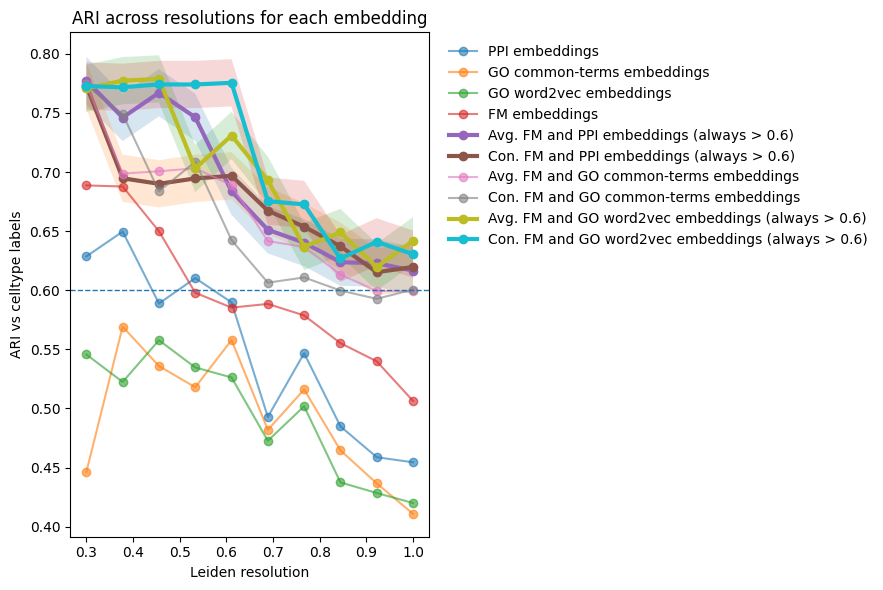

In [15]:
import numpy as np
import matplotlib.pyplot as plt

THRESH = 0.6

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig, ax = plt.subplots(figsize=(9, 6))

always_high = (
    ari_df.groupby("embedding")["ARI"]
    .apply(lambda s: (s > THRESH).all())
)
always_high_methods = always_high[always_high].index.tolist()

for name in ari_df["embedding"].unique():
    df_e = ari_df[ari_df["embedding"] == name].sort_values("resolution")

    x = df_e["resolution"].to_numpy()
    y = df_e["ARI"].to_numpy()

    if name in always_high_methods:
        ax.plot(x, y, marker="o", linewidth=3,
                label=f"{name} (always > {THRESH})")
        band = 0.02
        ax.fill_between(x,
                        np.clip(y - band, 0, 1),
                        np.clip(y + band, 0, 1),
                        alpha=0.18)
    else:
        ax.plot(x, y, marker="o", linewidth=1.5,
                alpha=0.6, label=name)

ax.axhline(THRESH, linestyle="--", linewidth=1)

ax.set_xlabel("Leiden resolution")
ax.set_ylabel("ARI vs celltype labels")
ax.set_title("ARI across resolutions for each embedding")

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()